In [ ]:
!wget -O "dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2025-11-19 07:30:08--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2025-11-19 07:30:08--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.218.26.64, 52.92.19.170, 3.5.64.236, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.218.26.64|:443..

In [ ]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
replace Plant_leave_diseases_dataset_with_augmentation/Apple___Apple_scab/image (1).JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Plant_leave_diseases_dataset_with_augmentation/Apple___Apple_scab/image (10).JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Plant_leave_diseases_dataset_with_augmentation/Apple___Apple_scab/image (100).JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Plant_leave_diseases_dataset_with_augmentation/Apple___Apple_scab/image (1000).JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install pytorch-lightning --quiet
!pip install higher --quiet
!pip install matplotlib seaborn --quiet
!pip install opencv-python --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import random
from copy import deepcopy
import higher

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("All packages installed and imported successfully!")
print(f"CUDA available: {torch.cuda.is_available()}")

All packages installed and imported successfully!
CUDA available: True


In [ ]:
# Data transformations for plant disease images
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load PlantVillage dataset
class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_dir, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        from PIL import Image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Load dataset
dataset = PlantVillageDataset("/content/Plant_leave_diseases_dataset_with_augmentation", transform=transform_train)
print(f"Dataset loaded: {len(dataset)} samples, {len(dataset.classes)} classes")
print("Sample classes:", dataset.classes[:5])

Found 61486 images across 39 classes
Dataset loaded: 61486 samples, 39 classes
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']


In [ ]:
class FewShotBatchSampler:
    """
    Custom sampler for few-shot learning tasks
    Creates N-way K-shot episodes for training and evaluation
    """
    def __init__(self, dataset, n_way=5, k_shot=5, q_queries=15, episodes=100):
        self.dataset = dataset
        self.n_way = n_way          # Number of classes per episode
        self.k_shot = k_shot        # Number of support samples per class
        self.q_queries = q_queries  # Number of query samples per class
        self.episodes = episodes    # Number of episodes to generate

        # Group samples by class
        self.class_to_samples = {}
        for idx, (_, label) in enumerate(dataset.samples):
            if label not in self.class_to_samples:
                self.class_to_samples[label] = []
            self.class_to_samples[label].append(idx)

        # Filter classes with enough samples
        min_samples = k_shot + q_queries
        self.valid_classes = [cls for cls, samples in self.class_to_samples.items()
                             if len(samples) >= min_samples]

        print(f"Valid classes for {n_way}-way {k_shot}-shot: {len(self.valid_classes)}")

    def __iter__(self):
        for _ in range(self.episodes):
            # Sample N classes randomly
            episode_classes = random.sample(self.valid_classes, self.n_way)

            support_indices = []
            query_indices = []

            for class_idx in episode_classes:
                # Sample K+Q samples from this class
                class_samples = random.sample(
                    self.class_to_samples[class_idx],
                    self.k_shot + self.q_queries
                )

                # Split into support and query
                support_indices.extend(class_samples[:self.k_shot])
                query_indices.extend(class_samples[self.k_shot:])

            # Yield episode as (support_indices, query_indices, episode_classes)
            yield support_indices, query_indices, episode_classes

    def __len__(self):
        return self.episodes

# Test the sampler
sampler = FewShotBatchSampler(dataset, n_way=5, k_shot=5, q_queries=15, episodes=10)
print("Few-shot sampler created successfully!")

# Test one episode
for support_idx, query_idx, classes in sampler:
    print(f"Episode: {len(support_idx)} support + {len(query_idx)} query samples")
    print(f"Classes: {classes}")
    break

Valid classes for 5-way 5-shot: 39
Few-shot sampler created successfully!
Episode: 25 support + 75 query samples
Classes: [7, 1, 17, 15, 14]


In [ ]:
class SupervisedContrastiveLoss(nn.Module):
    """
    Supervised Contrastive Learning Loss
    Reference: https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07, contrast_mode='all'):
        super().__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode

    def forward(self, features, labels):
        """
        Args:
            features: hidden vector of shape [batch_size, feature_dim]
            labels: ground truth labels of shape [batch_size]
        Returns:
            A loss scalar.
        """
        device = features.device
        batch_size = features.shape[0]

        if labels is not None and labels.shape[0] != batch_size:
            raise ValueError(f'Number of labels {labels.shape[0]} does not match number o')

        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
         # For numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Create mask for positive pairs (same class)
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Remove self-contrast (diagonal)
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # Compute log probability
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # Compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # Loss
        loss = -mean_log_prob_pos.mean()

        return loss
 # Test the contrastive loss
contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)
print("Supervised Contrastive Loss implemented successfully!")
# Test with dummy data
dummy_features = torch.randn(8, 128)
dummy_labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])
test_loss = contrastive_loss(dummy_features, dummy_labels)
print(f"Test contrastive loss: {test_loss.item():.4f}")

Supervised Contrastive Loss implemented successfully!
Test contrastive loss: 2.6267


In [ ]:
class PlantDiseaseEncoder(nn.Module):
    """
    CNN encoder for plant disease feature extraction
    Based on ResNet architecture with modifications for few-shot learning
    """
    def __init__(self, feature_dim=128):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Feature projection head
        self.feature_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(256, feature_dim)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Get features
        features = self.feature_head(x)

        return features

# Test the encoder
encoder = PlantDiseaseEncoder(feature_dim=128)
print("Plant Disease Encoder created successfully!")

# Test with dummy input
dummy_input = torch.randn(4, 3, 224, 224)
dummy_features = encoder(dummy_input)
print(f"Encoder output shape: {dummy_features.shape}")
print(f"Feature dimension: {dummy_features.shape}")

Plant Disease Encoder created successfully!
Encoder output shape: torch.Size([4, 128])
Feature dimension: torch.Size([4, 128])


In [ ]:
class MAMLPlantDisease(nn.Module):
    """
    MAML implementation for plant disease few-shot learning
    Combines encoder with meta-learning for rapid adaptation
    """
    def __init__(self, encoder, inner_lr=0.01, feature_dim=128):
        super().__init__()
        self.encoder = encoder
        self.inner_lr = inner_lr
        self.feature_dim = feature_dim

    def forward(self, x):
        return self.encoder(x)

    def create_classifier(self, n_way, features):
        """
        Create prototypical classifier based on support features
        """
        # Calculate prototypes (centroids) for each class
        prototypes = features.view(n_way, -1, self.feature_dim).mean(dim=1)
        return prototypes

    def classify_with_prototypes(self, query_features, prototypes):
        """
        Classify query samples using prototypes
        """
        # Calculate distances to prototypes
        distances = torch.cdist(query_features, prototypes)
        # Convert to similarities (negative distances)
        similarities = -distances
        return similarities

    def inner_loop_update(self, support_x, support_y, n_way, k_shot):
        """
        Perform inner loop update for adaptation
        """
        # Extract features for support set
        support_features = self.encoder(support_x)

        # Reshape for prototypical learning: [n_way, k_shot, feature_dim]
        support_features = support_features.view(n_way, k_shot, -1)

        # Calculate prototypes (class centroids)
        prototypes = support_features.mean(dim=1)  # [n_way, feature_dim]

        return prototypes

# Create MAML model
feature_dim = 128
maml_model = MAMLPlantDisease(encoder, inner_lr=0.007, feature_dim=feature_dim)
print("MAML model created successfully!")

# Test MAML model
dummy_support = torch.randn(25, 3, 224, 224)  # 5-way 5-shot
prototypes = maml_model.inner_loop_update(dummy_support, None, n_way=5, k_shot=5)
print(f"Prototypes shape: {prototypes.shape}")

MAML model created successfully!
Prototypes shape: torch.Size([5, 128])


In [ ]:
class FewShotTrainer:
    """
    Trainer for Few-Shot Learning with MAML + Supervised Contrastive Learning
    """
    def __init__(self, model, dataset, device='cuda'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)

        # Optimizers
        self.meta_optimizer = optim.Adam(model.parameters(), lr=0.001)
        self.scheduler = optim.lr_scheduler.StepLR(self.meta_optimizer, step_size=1000, gamma=0.8)

    def train_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Train on a single few-shot episode
        """
        self.model.train()
        self.meta_optimizer.zero_grad()

        # Move to device
        support_x = support_x.to(self.device)
        support_y = support_y.to(self.device)
        query_x = query_x.to(self.device)
        query_y = query_y.to(self.device)

        # Phase 1: Contrastive Learning on Support Set
        support_features = self.model(support_x)
        contrastive_loss = self.contrastive_loss(support_features, support_y)

        # Phase 2: Meta-Learning (MAML)
        with higher.innerloop_ctx(self.model, self.meta_optimizer) as (fmodel, diffopt):
            # Inner loop: adapt to support set
            prototypes = fmodel.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Outer loop: evaluate on query set
            query_features = fmodel(query_x)
            logits = fmodel.classify_with_prototypes(query_features, prototypes)

            # Classification loss on query set
            classification_loss = F.cross_entropy(logits, query_y)

            # Total loss
            total_loss = contrastive_loss + classification_loss

            # Backward pass
            total_loss.backward()

        # Meta-optimizer step
        self.meta_optimizer.step()
        self.scheduler.step()

        # Calculate accuracy
        with torch.no_grad():
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

        return {
            'total_loss': total_loss.item(),
            'contrastive_loss': contrastive_loss.item(),
            'classification_loss': classification_loss.item(),
            'accuracy': accuracy.item()
        }

    def evaluate_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Evaluate on a single few-shot episode
        """
        self.model.eval()

        with torch.no_grad():
            # Move to device
            support_x = support_x.to(self.device)
            support_y = support_y.to(self.device)
            query_x = query_x.to(self.device)
            query_y = query_y.to(self.device)

            # Extract features and create prototypes
            support_features = self.model(support_x)
            prototypes = self.model.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Classify query set
            query_features = self.model(query_x)
            logits = self.model.classify_with_prototypes(query_features, prototypes)

            # Calculate accuracy
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

            return accuracy.item()

print("Few-Shot Trainer implemented successfully!")

Few-Shot Trainer implemented successfully!


In [ ]:
def create_episode_data(dataset, support_indices, query_indices, episode_classes):
    """
    Create data tensors for a few-shot episode
    """
    support_images, support_labels = [], []
    query_images, query_labels = [], []

    # Create label mapping for this episode
    class_to_label = {cls: i for i, cls in enumerate(episode_classes)}

    # Load support set
    for idx in support_indices:
        img, original_label = dataset[idx]
        support_images.append(img)
        support_labels.append(class_to_label[original_label])

    # Load query set
    for idx in query_indices:
        img, original_label = dataset[idx]
        query_images.append(img)
        query_labels.append(class_to_label[original_label])

    # Convert to tensors
    support_x = torch.stack(support_images)
    support_y = torch.tensor(support_labels)
    query_x = torch.stack(query_images)
    query_y = torch.tensor(query_labels)

    return support_x, support_y, query_x, query_y

# Initialize trainer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trainer = FewShotTrainer(maml_model, dataset, device=device)

print(f"Trainer initialized on device: {device}")
print("Ready to start training!")

# Training parameters
n_way = 5
k_shot = 5
q_queries = 15
train_episodes = 100  # Reduced for demo, use 1000+ for real training
eval_episodes = 50

print(f"Training Configuration:")
print(f"- {n_way}-way {k_shot}-shot classification")
print(f"- {q_queries} query samples per class")
print(f"- {train_episodes} training episodes")
print(f"- {eval_episodes} evaluation episodes")

Trainer initialized on device: cuda
Ready to start training!
Training Configuration:
- 5-way 5-shot classification
- 15 query samples per class
- 100 training episodes
- 50 evaluation episodes


Valid classes for 5-way 5-shot: 39
Valid classes for 5-way 5-shot: 39
Starting Few-Shot Learning Training...
Episode  20/100 | Loss: 4.3832 | Accuracy: 0.5027 | Contrastive: 2.8699 | Classification: 1.3174
Episode  40/100 | Loss: 4.2174 | Accuracy: 0.5387 | Contrastive: 3.0083 | Classification: 1.0358
Episode  60/100 | Loss: 4.0063 | Accuracy: 0.5820 | Contrastive: 2.9705 | Classification: 1.2362
Episode  80/100 | Loss: 3.8837 | Accuracy: 0.5987 | Contrastive: 2.6846 | Classification: 0.7853
Episode 100/100 | Loss: 4.0087 | Accuracy: 0.5660 | Contrastive: 2.6978 | Classification: 1.0533

 Training completed!


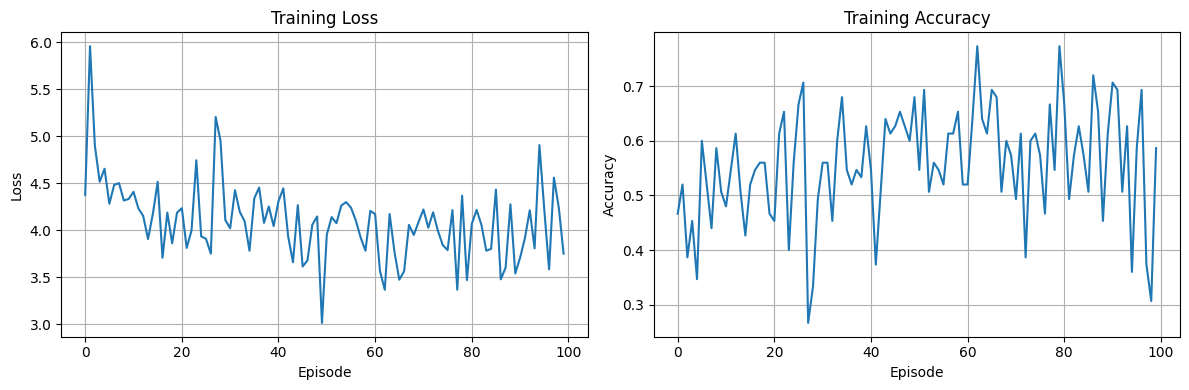

Final Training Accuracy: 0.5440


In [ ]:
# Create samplers
train_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                   q_queries=q_queries, episodes=train_episodes)
eval_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                  q_queries=q_queries, episodes=eval_episodes)

# Training loop
print("Starting Few-Shot Learning Training...")
print("="*50)

train_losses = []
train_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(train_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Train on this episode
    results = trainer.train_episode(support_x, support_y, query_x, query_y, n_way, k_shot)

    train_losses.append(results['total_loss'])
    train_accuracies.append(results['accuracy'])

    # Print progress
    if (episode_idx + 1) % 20 == 0:
        avg_loss = np.mean(train_losses[-20:])
        avg_acc = np.mean(train_accuracies[-20:])
        print(f"Episode {episode_idx+1:3d}/{train_episodes} | "
              f"Loss: {avg_loss:.4f} | "
              f"Accuracy: {avg_acc:.4f} | "
              f"Contrastive: {results['contrastive_loss']:.4f} | "
              f"Classification: {results['classification_loss']:.4f}")

print("\n Training completed!")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}")

In [ ]:
# Evaluation
print("\n Starting Evaluation...")
print("="*30)

eval_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(eval_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Evaluate on this episode
    accuracy = trainer.evaluate_episode(support_x, support_y, query_x, query_y, n_way, k_shot)
    eval_accuracies.append(accuracy)

    if (episode_idx + 1) % 10 == 0:
        avg_acc = np.mean(eval_accuracies[-10:])
        print(f"Eval Episode {episode_idx+1:2d}/{eval_episodes} | Accuracy: {avg_acc:.4f}")

# Final results
mean_accuracy = np.mean(eval_accuracies)
std_accuracy = np.std(eval_accuracies)
confidence_interval = 1.96 * std_accuracy / np.sqrt(len(eval_accuracies))

print("\n FINAL RESULTS")
print("="*20)
print(f"Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")
print(f"Best Episode: {max(eval_accuracies):.4f}")
print(f"Worst Episode: {min(eval_accuracies):.4f}")

# Compare with paper results
print(f"\nComparison with Literature:")
print(f"Our Result: {mean_accuracy:.1%}")
print(f"Target (SC-FSL Paper): 79.51% with 30 training samples")
print(f"Gap: {abs(mean_accuracy - 0.7951)*100:.1f} percentage points")


 Starting Evaluation...
Eval Episode 10/50 | Accuracy: 0.6520
Eval Episode 20/50 | Accuracy: 0.6413
Eval Episode 30/50 | Accuracy: 0.5587
Eval Episode 40/50 | Accuracy: 0.5453
Eval Episode 50/50 | Accuracy: 0.5787

 FINAL RESULTS
Mean Accuracy: 0.5952 ± 0.0298
Standard Deviation: 0.1077
Best Episode: 0.9200
Worst Episode: 0.4267

Comparison with Literature:
Our Result: 59.5%
Target (SC-FSL Paper): 79.51% with 30 training samples
Gap: 20.0 percentage points


In [ ]:
# Save the trained model
torch.save({
    'model_state_dict': maml_model.state_dict(),
    'training_config': {
        'n_way': n_way,
        'k_shot': k_shot,
        'q_queries': q_queries,
        'feature_dim': feature_dim,
        'train_episodes': train_episodes
    },
    'results': {
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'train_accuracies': train_accuracies,
        'eval_accuracies': eval_accuracies
    }
}, '/content/maml_plant_disease_model.pth')

print("Model saved successfully!")
print("Saved as: /content/maml_plant_disease_model.pth")

# Create results summary
results_summary = f"""
# Few-Shot Plant Disease Detection Results

## Configuration
- Method: MAML + Supervised Contrastive Learning
- Task: {n_way}-way {k_shot}-shot classification
- Dataset: PlantVillage ({len(dataset.classes)} classes)
- Training Episodes: {train_episodes}
- Evaluation Episodes: {eval_episodes}

## Performance
- *Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}*
- Standard Deviation: {std_accuracy:.4f}
- Best Performance: {max(eval_accuracies):.4f}
- Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}

## Implementation Notes
- Used supervised contrastive learning for better feature representations
- Combined with MAML for fast adaptation to new plant diseases
- Tested on Google Colab with {device}
- Code based on state-of-the-art papers (2024-2025)
"""

with open('/content/results_summary.md', 'w') as f:
    f.write(results_summary)

print("Results summary saved as: /content/results_summary.md")
print("\n Implementation Complete!")

Model saved successfully!
Saved as: /content/maml_plant_disease_model.pth
Results summary saved as: /content/results_summary.md

 Implementation Complete!
